In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!pip install scikit-learn

In [ ]:
#Install libraries
from pathlib import Path
import pandas as pd
import os.path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
# Drive Path
image_dir = Path('/content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images')

In [ ]:
# Get Images into colab
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

# Get all images.
num_samples = len(images)
image_df = images.sample(n=num_samples, random_state=1).reset_index(drop=True)

print(f"Selected {len(image_df)} images for processing.")

Selected 101014 images for processing.


In [ ]:
# Subset dataset to a lower number of outputs
label_counts = image_df['Label'].value_counts()
num_classes_to_remove = int(len(label_counts) * 0.8)

# Get the labels with the lowest counts
labels_to_remove = label_counts.nsmallest(num_classes_to_remove).index.tolist()

# Filter image_df to exclude these labels
filtered_image_df = image_df[~image_df['Label'].isin(labels_to_remove)]

print(f"Original number of images: {len(image_df)}")
print(f"Number of classes removed: {num_classes_to_remove}")
print(f"Number of classes kept: {101-num_classes_to_remove}")
print(f"New total count of images after filtering: {len(filtered_image_df)}")

image_df = filtered_image_df.copy()

Original number of images: 101014
Number of classes removed: 80
Number of classes kept: 21
New total count of images after filtering: 21014


In [ ]:
print("Labels kept:", image_df['Label'].unique())

Labels kept: ['paella' 'samosa' 'caesar_salad' 'baby_back_ribs' 'chocolate_cake'
 'lobster_roll_sandwich' 'crab_cakes' 'deviled_eggs' 'omelette' 'churros'
 'grilled_salmon' 'ceviche' 'cheesecake' 'hot_dog' 'takoyaki'
 'french_onion_soup' 'tiramisu' 'seaweed_salad' 'fried_calamari'
 'pork_chop' 'pad_thai']


In [ ]:
# Split dataset into test and training
train_df, test_df = train_test_split(
    image_df,
    train_size=0.7,
    shuffle=True,
    random_state=42)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
  validation_split=0.2
)

In [ ]:
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

## Full 224x224 Resolution MobileNetV2 21 Output LR=0.0005

In [ ]:
train_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 11768 validated image filenames belonging to 21 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 2941 validated image filenames belonging to 21 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 6305 validated image filenames belonging to 21 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
  input_shape=(224, 224, 3),
  include_top=False,
  weights='imagenet',
  pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(224, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(224, activation='relu')(x)
outputs = tf.keras.layers.Dense(21, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,600,053 (9.92 MB)

 Trainable params: 342,069 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 10817s 29s/step - accuracy: 0.4825 - loss: 1.7597 - val_accuracy: 0.6998 - val_loss: 0.9476
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 160ms/step - accuracy: 0.7616 - loss: 0.7726 - val_accuracy: 0.7127 - val_loss: 0.9271
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 159ms/step - accuracy: 0.8140 - loss: 0.5914 - val_accuracy: 0.7110 - val_loss: 0.9841
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 58s 157ms/step - accuracy: 0.8564 - loss: 0.4643 - val_accuracy: 0.7239 - val_loss: 0.9192
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 160ms/step - accuracy: 0.8894 - loss: 0.3563 - val_accuracy: 0.7181 - val_loss: 0.9930
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 58s 157ms/step - accuracy: 0.9183 - loss: 0.2811 - val_accuracy: 0.7168 - val_loss: 1.0493
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 58s 157ms/step - accuracy: 0.9436 - loss: 0.2020 - val_accuracy: 0.7178 - val_loss: 1.1014


In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 72.97%


In [ ]:
model.save('food_detection_model(MobileNetV2-21 Output-LR:0.0005).keras')

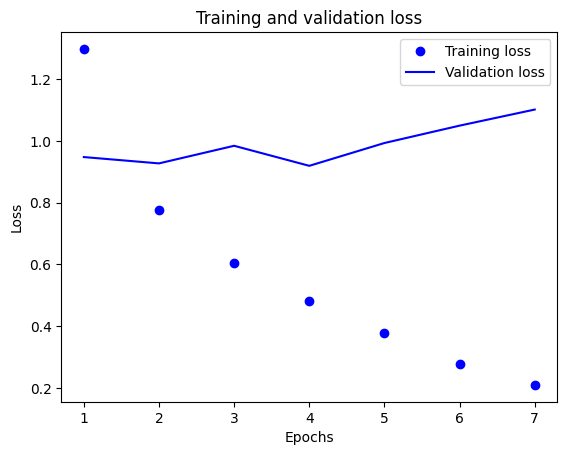

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

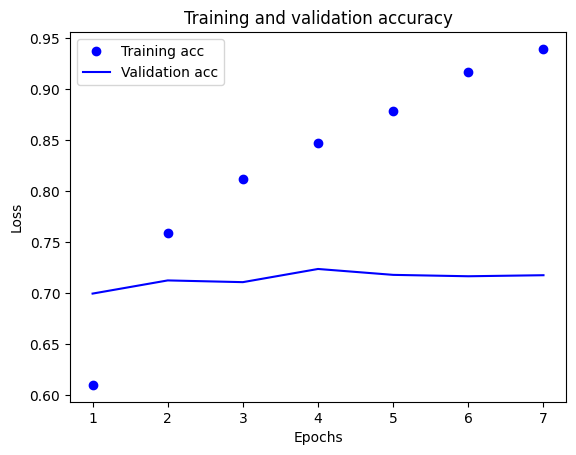

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

## Full 224x224 Resolution MobileNetV2 21 Output LR=0.0005 L2 Weight Regularization

In [ ]:
train_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 11768 validated image filenames belonging to 21 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 2941 validated image filenames belonging to 21 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 6305 validated image filenames belonging to 21 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
  input_shape=(224, 224, 3),
  include_top=False,
  weights='imagenet',
  pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(pretrained_model.output)
x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
outputs = tf.keras.layers.Dense(21, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,600,053 (9.92 MB)

 Trainable params: 342,069 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 7641s 21s/step - accuracy: 0.4844 - loss: 2.3216 - val_accuracy: 0.6838 - val_loss: 1.4929
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 163ms/step - accuracy: 0.7580 - loss: 1.2534 - val_accuracy: 0.6902 - val_loss: 1.4357
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 162ms/step - accuracy: 0.7948 - loss: 1.0785 - val_accuracy: 0.7222 - val_loss: 1.2931
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.8375 - loss: 0.9241 - val_accuracy: 0.7239 - val_loss: 1.2935
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.8612 - loss: 0.8176 - val_accuracy: 0.7270 - val_loss: 1.2844
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 163ms/step - accuracy: 0.8920 - loss: 0.7198 - val_accuracy: 0.7270 - val_loss: 1.2805
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.9198 - loss: 0.6473 - val_accuracy: 0.7174 - val_loss: 1.3315
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.9243 - loss: 0

In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 73.28%


In [ ]:
model.save('food_detection_model(MobileNetV2-21 Output-LR:0.0005-L2).keras')

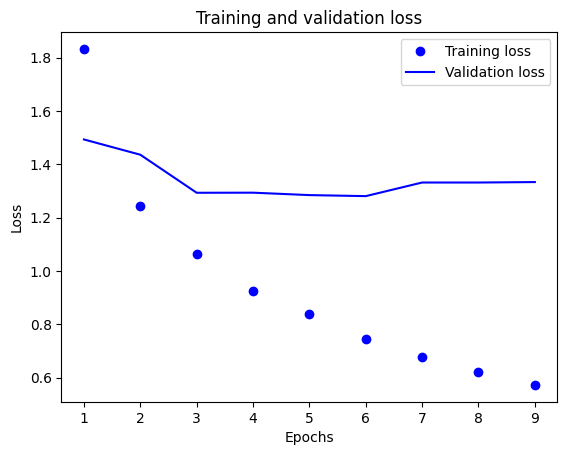

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

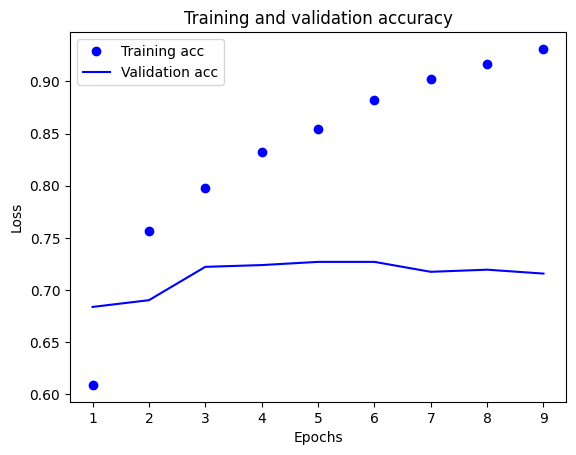

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

## Full 224x224 Resolution MobileNetV2 21 Output LR=0.001 L2 Weight Regularization

In [ ]:
train_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 11768 validated image filenames belonging to 21 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 2941 validated image filenames belonging to 21 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 6305 validated image filenames belonging to 21 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
  input_shape=(224, 224, 3),
  include_top=False,
  weights='imagenet',
  pooling='avg'
)

pretrained_model.trainable = False

In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(pretrained_model.output)
x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
outputs = tf.keras.layers.Dense(21, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,600,053 (9.92 MB)

 Trainable params: 342,069 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 86s 206ms/step - accuracy: 0.4861 - loss: 2.3066 - val_accuracy: 0.6953 - val_loss: 1.4494
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 162ms/step - accuracy: 0.7587 - loss: 1.2316 - val_accuracy: 0.6970 - val_loss: 1.3898
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 162ms/step - accuracy: 0.8070 - loss: 1.0374 - val_accuracy: 0.7083 - val_loss: 1.3113
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 164ms/step - accuracy: 0.8364 - loss: 0.8936 - val_accuracy: 0.7188 - val_loss: 1.2944
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 61s 165ms/step - accuracy: 0.8693 - loss: 0.7957 - val_accuracy: 0.7069 - val_loss: 1.3351
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 164ms/step - accuracy: 0.8813 - loss: 0.7361 - val_accuracy: 0.7249 - val_loss: 1.2826
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 60s 163ms/step - accuracy: 0.9059 - loss: 0.6576 - val_accuracy: 0.7100 - val_loss: 1.3529
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 59s 161ms/step - accuracy: 0.9202 - loss: 0

In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 73.66%


In [ ]:
model.save('food_detection_model(MobileNetV2-21 Output-LR:0.001-L2).keras')

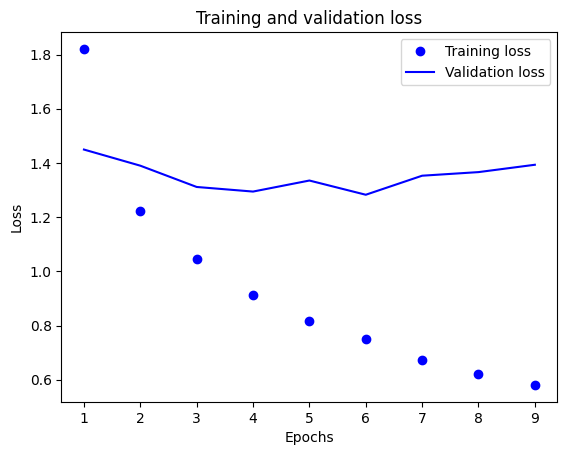

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

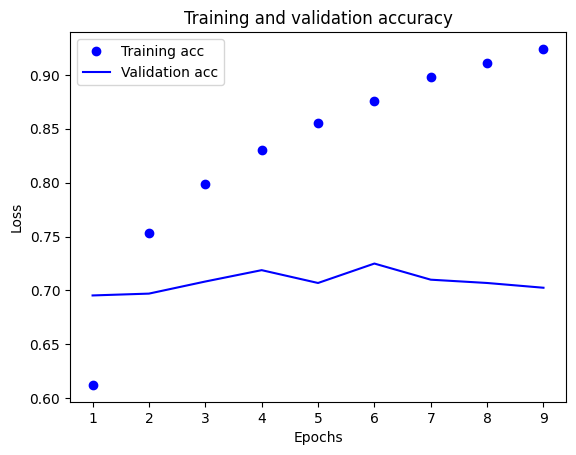

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

## Full 224x224 Resolution MobileNetV2 101 Output Model

In [ ]:
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

# Get all images.
num_samples = len(images)
image_df = images.sample(n=num_samples, random_state=1).reset_index(drop=True)

print(f"Selected {len(image_df)} images for processing.")

Selected 101014 images for processing.


In [ ]:
print("Labels kept:", image_df['Label'].unique())

Labels kept: ['chicken_wings' 'prime_rib' 'panna_cotta' 'sushi' 'shrimp_and_grits'
 'pancakes' 'carrot_cake' 'nachos' 'huevos_rancheros' 'creme_brulee'
 'chicken_curry' 'french_fries' 'oysters' 'paella' 'baklava'
 'garlic_bread' 'filet_mignon' 'waffles' 'pulled_pork_sandwich' 'gnocchi'
 'fried_rice' 'beignets' 'beef_carpaccio' 'pizza' 'beef_tartare'
 'macarons' 'tacos' 'clam_chowder' 'frozen_yogurt' 'spaghetti_bolognese'
 'cup_cakes' 'tuna_tartare' 'lasagna' 'fish_and_chips' 'mussels' 'poutine'
 'steak' 'club_sandwich' 'chicken_quesadilla' 'guacamole' 'donuts'
 'cannoli' 'foie_gras' 'lobster_bisque' 'breakfast_burrito' 'greek_salad'
 'miso_soup' 'eggs_benedict' 'french_toast' 'sashimi' 'apple_pie'
 'chocolate_mousse' 'edamame' 'hot_and_sour_soup' 'macaroni_and_cheese'
 'bread_pudding' 'bibimbap' 'falafel' 'beet_salad' 'gyoza' 'dumplings'
 'bruschetta' 'ramen' 'croque_madame' 'ravioli' 'hamburger'
 'red_velvet_cake' 'scallops' 'hummus' 'risotto' 'pho' 'caprese_salad'
 'strawberry_shortc

In [ ]:
train_df, test_df = train_test_split(
    image_df,
    train_size=0.7,
    shuffle=True,
    random_state=42)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
  validation_split=0.2
)

In [ ]:
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 56568 validated image filenames belonging to 101 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 14141 validated image filenames belonging to 101 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 30305 validated image filenames belonging to 101 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
  input_shape=(224, 224, 3),
  include_top=False,
  weights='imagenet',
  pooling='avg'
)

pretrained_model.trainable = False

In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(224, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(224, activation='relu')(x)
outputs = tf.keras.layers.Dense(101, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,618,053 (9.99 MB)

 Trainable params: 360,069 (1.37 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

Epoch 1/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 27882s 16s/step - accuracy: 0.3334 - loss: 2.8199 - val_accuracy: 0.5221 - val_loss: 1.8637
Epoch 2/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 288s 163ms/step - accuracy: 0.5652 - loss: 1.6429 - val_accuracy: 0.5442 - val_loss: 1.7628
Epoch 3/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 285s 161ms/step - accuracy: 0.6165 - loss: 1.4173 - val_accuracy: 0.5451 - val_loss: 1.7749
Epoch 4/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 283s 160ms/step - accuracy: 0.6596 - loss: 1.2490 - val_accuracy: 0.5601 - val_loss: 1.7320
Epoch 5/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 284s 160ms/step - accuracy: 0.6957 - loss: 1.1074 - val_accuracy: 0.5521 - val_loss: 1.7899
Epoch 6/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 284s 161ms/step - accuracy: 0.7304 - loss: 0.9665 - val_accuracy: 0.5548 - val_loss: 1.8303
Epoch 7/10
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 286s 162ms/step - accuracy: 0.7649 - loss: 0.8333 - val_accuracy: 0.5473 - val_loss: 1.9343


In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 56.14%


In [ ]:
model.save('food_detection_model(MobileNetV2-101 Output- Full Res).keras')

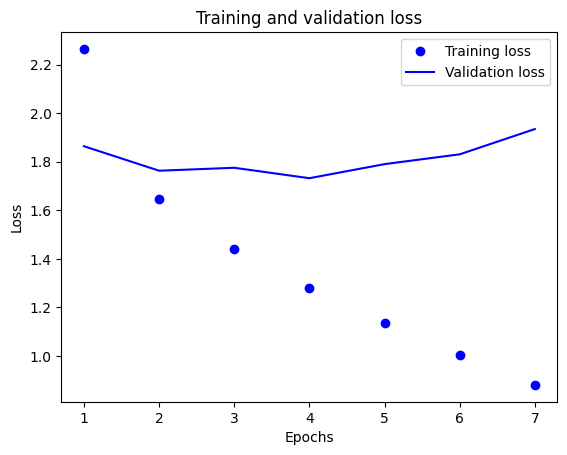

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

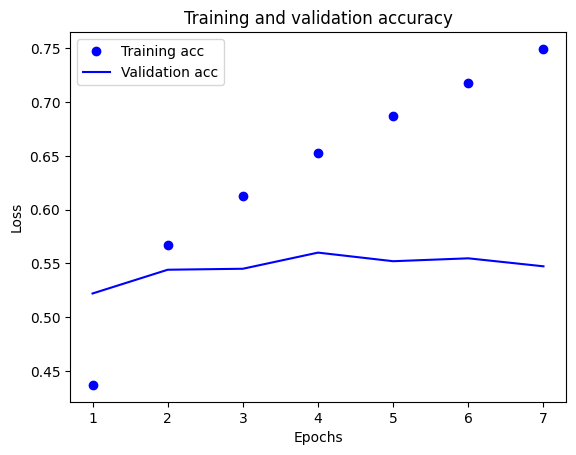

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

## Full 224x224 Resolution MobileNetV2 21 Output LR=0.0005 with Dropout

In [ ]:
label_counts = image_df['Label'].value_counts()
num_classes_to_remove = int(len(label_counts) * 0.8)

# Get the labels with the lowest counts
labels_to_remove = label_counts.nsmallest(num_classes_to_remove).index.tolist()

# Filter image_df to exclude these labels
filtered_image_df = image_df[~image_df['Label'].isin(labels_to_remove)]

print(f"Original number of images: {len(image_df)}")
print(f"Number of classes removed: {num_classes_to_remove}")
print(f"Number of classes kept: {101-num_classes_to_remove}")
print(f"New total count of images after filtering: {len(filtered_image_df)}")

image_df = filtered_image_df.copy()

Original number of images: 101014
Number of classes removed: 80
Number of classes kept: 21
New total count of images after filtering: 21014


In [ ]:
print("Labels kept:", image_df['Label'].unique())

Labels kept: ['paella' 'samosa' 'caesar_salad' 'baby_back_ribs' 'chocolate_cake'
 'lobster_roll_sandwich' 'crab_cakes' 'deviled_eggs' 'omelette' 'churros'
 'grilled_salmon' 'ceviche' 'cheesecake' 'hot_dog' 'takoyaki'
 'french_onion_soup' 'tiramisu' 'seaweed_salad' 'fried_calamari'
 'pork_chop' 'pad_thai']


In [ ]:
train_df, test_df = train_test_split(
    image_df,
    train_size=0.7,
    shuffle=True,
    random_state=42)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
  validation_split=0.2
)

In [ ]:
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='training'
)

Found 11768 validated image filenames belonging to 21 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
  dataframe=train_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=True,
  seed=42,
  subset='validation'
)

Found 2941 validated image filenames belonging to 21 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
  dataframe=test_df,
  x_col='Filepath',
  y_col='Label',
  target_size=(224, 224),
  color_mode='rgb',
  class_mode='categorical',
  batch_size=32,
  shuffle=False
)

Found 6305 validated image filenames belonging to 21 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
  input_shape=(224, 224, 3),
  include_top=False,
  weights='imagenet',
  pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(pretrained_model.output)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(224, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
outputs = tf.keras.layers.Dense(21, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,600,053 (9.92 MB)

 Trainable params: 342,069 (1.30 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True)])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 5227s 14s/step - accuracy: 0.3345 - loss: 2.5213 - val_accuracy: 0.6743 - val_loss: 1.3579
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 208ms/step - accuracy: 0.6384 - loss: 1.4338 - val_accuracy: 0.7032 - val_loss: 1.2386
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 76s 207ms/step - accuracy: 0.7059 - loss: 1.2298 - val_accuracy: 0.7164 - val_loss: 1.1684
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 75s 204ms/step - accuracy: 0.7225 - loss: 1.1487 - val_accuracy: 0.7181 - val_loss: 1.1656
Epoch 5/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 78s 213ms/step - accuracy: 0.7510 - loss: 1.0532 - val_accuracy: 0.7334 - val_loss: 1.1359
Epoch 6/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 83s 226ms/step - accuracy: 0.7667 - loss: 0.9938 - val_accuracy: 0.7208 - val_loss: 1.1593
Epoch 7/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 78s 212ms/step - accuracy: 0.7880 - loss: 0.9270 - val_accuracy: 0.7225 - val_loss: 1.1399
Epoch 8/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 78s 211ms/step - accuracy: 0.7929 - loss: 0

In [ ]:
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 74.23%


In [ ]:
model.save('food_detection_model(MobileNetV2-21 Output-LR:0.0005-Dropout).keras')

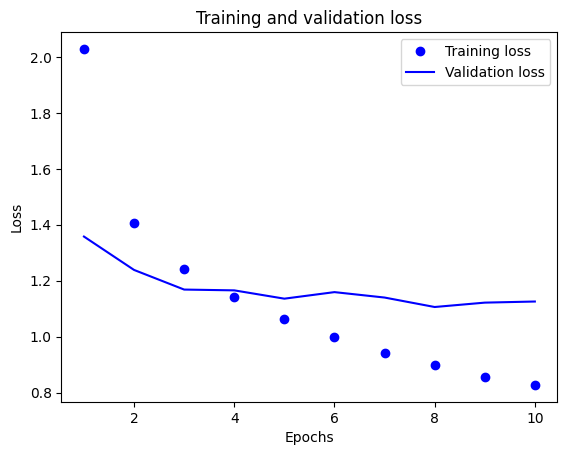

In [ ]:
## Loss Graphs
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']

# Define the lenght of the x axis
epochs = range(1, len(acc) + 1)

# Plot each metric and format the graph
plt.plot(epochs, loss_values, 'bo', label='Training loss')      # “bo” is for “blue dot.”
plt.plot(epochs, val_loss_values, 'b', label='Validation loss') # “b” is for “solid blue line.”
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()

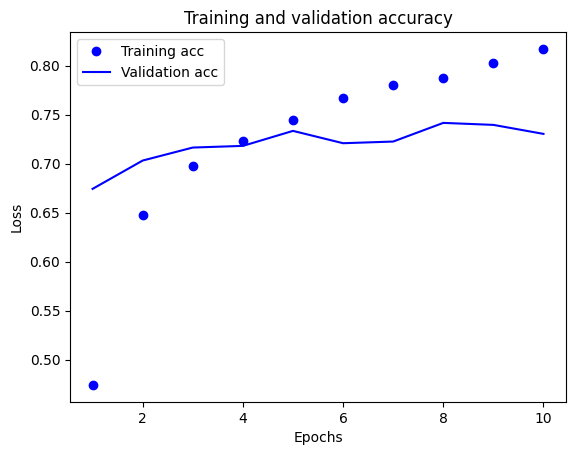

In [ ]:
## Accuracy Graphs
plt.clf()

# First, store the metrics into different objects
val_acc_values = history_dict['val_accuracy']

# Plot each metric and format the graph
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Print the graph.
plt.show()